In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Generate the Datasets

In [2]:
points = np.array([[0., 0., 1., 1.],
                   [0., 1., 0., 1.]])

xor_labels = np.array([-1, 1, 1, -1])
or_labels = np.array([-1, 1, 1, 1])

Choose dataset

In [3]:
labels = xor_labels

## Plot Dataset

[0. 0. 1. 1.]
[0. 1. 0. 1.]


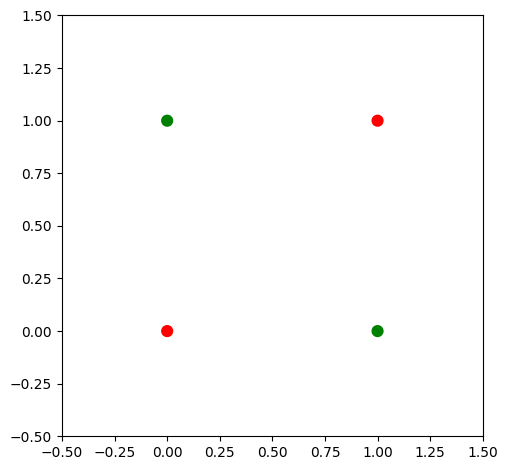

In [4]:
label_colors = {-1: 'r', 1: 'g'}
colors = list(map(lambda x: label_colors[x], labels))

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
print(points[0,:])
print(points[1,:])

ax.scatter(points[0,:], points[1,:], c=list(colors), s=60)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_aspect("equal")
fig.tight_layout()

## Create the Perceptron Classifier

In [5]:
weights = np.random.rand(3)
eta = 0.2

In [6]:
def perceptron(data, label):
    global weights, eta
    print(weights)
    data_ext = np.ones(3)
    data_ext[:2] = data
    prod = np.dot(weights, data_ext)
    pred = np.sign(prod)
    weights = weights + eta * (label - pred) * data_ext

def update_perceptron():
    global weights
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    ax.scatter(points[0,:], points[1,:], c=list(colors), s=60)
    if np.abs(weights[1]) > 0.0001:
        x_vals = np.arange(-0.5, 1.6, 0.1)
        y_vals = -(x_vals * weights[0])/weights[1] - weights[2]
        ax.plot(x_vals, y_vals, linewidth=2, color='black')
    else:
        ax.axvline(x=-(weights[2]/weights[1]), ymin=-0.5, ymax=1.5, linewidth=2, color='black')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_aspect("equal")
    fig.tight_layout()

In [7]:
i = 2

[0.62810388 0.52018013 0.87615789]
Selected point [0. 0.] -> -1
Computed weights [0.62810388 0.52018013 0.47615789]
Prediction 1.0


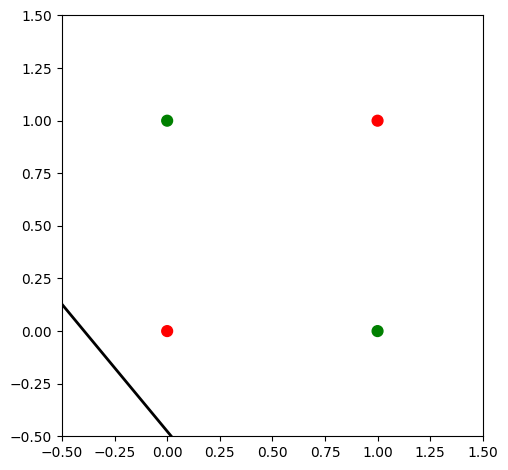

In [8]:
i = (i + 2) % 4
perceptron(points[:,i], labels[i])
print("Selected point {} -> {}".format(points[:,i], labels[i]))
print("Computed weights {}".format(weights))
print("Prediction {}".format(np.sign(points[0,i]*weights[0] + points[1,i]*weights[1] + weights[2])))
update_perceptron()